# **1. Data Profiling**

**1.1. News**

In [ ]:
import pandas as pd
df_news = pd.read_csv('/content/df_news.csv')
df_news.head()

,ticker,title,sapo,content,publish_time,url
0,VIC,"Chứng khoán ngày 26/2: VIC hồi phục, VN-Index ...",Thị trường chứng khoán ngày 26/2 ghi nhận dòng...,TIN MỚI\n\n\n\n\nVN-Index tăng 19 điểm phiên 2...,2026-02-26 17:47:00,https://cafef.vn/chung-khoan-ngay-26-2-vic-hoi...
1,VIC,Vingroup (VIC) ghi nhận doanh thu năm 2025 đạt...,"Tại ngày 31/12/2025, tổng tài sản Vingroup 1,1...",TIN MỚI\n\n\n\n\n Tập đoàn Vingroup (mã chứ...,2026-01-30 14:10:00,https://cafef.vn/vingroup-vic-ghi-nhan-doanh-t...
2,VIC,"""Cá mập"" Pyn Elite Fund: Không nắm giữ VIC khi...",Việc không nắm giữ cổ phiếu nhóm Vingroup khiế...,TIN MỚI\n\n\n\n\n Trong thư gửi nhà đầu tư ...,2026-01-08 14:34:00,https://cafef.vn/ca-map-pyn-elite-fund-neu-ly-...
3,VIC,"Chứng khoán ngày cuối năm 2025: Gần 3,9 tỷ cổ ...","Giữa lúc 3,9 tỷ cổ phiếu VIC 'nhập cuộc' củng ...",TIN MỚI\n\n\n\n\n Ngày giao dịch cuối cùng ...,2025-12-31 00:03:00,https://cafef.vn/chung-khoan-ngay-cuoi-nam-202...
4,VIC,"Cổ phiếu VIC vừa phá đỉnh lịch sử, tỷ phú Phạm...",Tập đoàn Vingroup vừa công bố hoàn tất đợt chà...,VIC: \n\n\n\n\nGiá hiện tại\n\n\n\n\nThay đổi\...,2025-12-24 00:21:00,https://cafef.vn/co-phieu-vic-vua-pha-dinh-lic...


In [ ]:
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        1395 non-null   object
 1   title         1395 non-null   object
 2   sapo          1390 non-null   object
 3   content       1395 non-null   object
 4   publish_time  1395 non-null   object
 5   url           1395 non-null   object
dtypes: object(6)
memory usage: 65.5+ KB


In [ ]:
df_news['ticker'].value_counts()

,count
ticker,
VIC,591
HAG,509
TTF,295


In [ ]:
df_news.nunique()

,0
ticker,3
title,1394
sapo,1315
content,1394
publish_time,1394
url,1395


**1.2. Price**

In [ ]:
df_price = pd.read_csv('/content/df_price.csv')
df_price.head()

,time,open,high,low,close,volume,ticker
0,2016-01-04 07:00:00,12.34,12.82,12.20,12.82,4809120,VIC
1,2016-01-05 07:00:00,12.69,12.88,12.63,12.82,2480100,VIC
2,2016-01-06 07:00:00,12.79,12.93,12.60,12.82,1976280,VIC
3,2016-01-07 07:00:00,12.63,13.01,12.55,12.96,2852010,VIC
4,2016-01-08 07:00:00,12.82,12.96,12.69,12.96,1641950,VIC


In [ ]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7599 entries, 0 to 7598
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    7599 non-null   object 
 1   open    7599 non-null   float64
 2   high    7599 non-null   float64
 3   low     7599 non-null   float64
 4   close   7599 non-null   float64
 5   volume  7599 non-null   int64  
 6   ticker  7599 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 415.7+ KB


**Conclusion:**


1.   Sapo column in df_news have 5 null data.
2.   Time column in df_price and publish_time column in df_news are wrong data types




# **2. Data Processing**

**2.1. Data Cleaning**

In [ ]:
df_news = df_news.drop_duplicates()
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        1395 non-null   object
 1   title         1395 non-null   object
 2   sapo          1390 non-null   object
 3   content       1395 non-null   object
 4   publish_time  1395 non-null   object
 5   url           1395 non-null   object
dtypes: object(6)
memory usage: 65.5+ KB


In [ ]:
df_news[df_news.isnull().any(axis=1)]

,ticker,title,sapo,content,publish_time,url
355,VIC,VIC: Nhận chuyển nhượng vốn điều lệ công ty Vi...,NaN,VIC&: \n\n\n\n\nGiá hiện tại\n\n\n\n\nThay đổi...,2013-06-03 17:44:00,https://cafef.vn/doanh-nghiep/vic-nhan-chuyen-...
358,VIC,VIC: Nhận chuyển nhượng cổ phần trong Xavinco,NaN,VIC&: \n\n\n\n\nGiá hiện tại\n\n\n\n\nThay đổi...,2013-05-13 21:58:00,https://cafef.vn/doanh-nghiep/vic-nhan-chuyen-...
1013,HAG,HAG: Cố định tỷ lệ nắm giữ của nhà đầu tư nước...,NaN,HAG&: \n\n\n\n\nGiá hiện tại\n\n\n\n\nThay đổi...,2010-09-17 17:41:00,https://cafef.vn/doanh-nghiep/hag-co-dinh-ty-l...
1015,HAG,31/08/2010 - HAG tổ chức roadshow giới thiệu t...,NaN,TIN MỚI\n\n\n\n\nHAG tổ chức roadshow giới thi...,2010-08-24 12:29:00,https://cafef.vn/hoi-nghi-hoi-thao/31082010-ha...
1269,TTF,"TTF, VHG, TLG, HVG: Thông tin giao dịch lượng ...",NaN,TTF&TLG&VHG&HVG&: \n\n\n\n\nGiá hiện tại\n\n\n...,2013-07-18 21:39:00,https://cafef.vn/doanh-nghiep/ttf-vhg-tlg-hvg-...


In [ ]:
df_news.fillna(value='unknown', inplace=True)
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        1395 non-null   object
 1   title         1395 non-null   object
 2   sapo          1395 non-null   object
 3   content       1395 non-null   object
 4   publish_time  1395 non-null   object
 5   url           1395 non-null   object
dtypes: object(6)
memory usage: 65.5+ KB


**2.2. Data Transforming**

In [ ]:
df_news['publish_time'] = pd.to_datetime(df_news['publish_time'])
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ticker        1395 non-null   object        
 1   title         1395 non-null   object        
 2   sapo          1395 non-null   object        
 3   content       1395 non-null   object        
 4   publish_time  1395 non-null   datetime64[ns]
 5   url           1395 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 65.5+ KB


In [ ]:
df_price['time'] = pd.to_datetime(df_price['time'])
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7599 entries, 0 to 7598
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    7599 non-null   datetime64[ns]
 1   open    7599 non-null   float64       
 2   high    7599 non-null   float64       
 3   low     7599 non-null   float64       
 4   close   7599 non-null   float64       
 5   volume  7599 non-null   int64         
 6   ticker  7599 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 415.7+ KB


**2.3. Time Mapping**


---


A significant challenge in the Vietnamese market is the irregular holiday schedule (e.g., Lunar New Year) and the after-hours publication of news. To map news to the correct trading session without relying on a hard-coded holiday calendar, the system utilizes Pandas' merge_asof function with a forward direction.


*   After-hours logic: Any news published after 15:00 (market close) is computationally shifted to the next day (Target_Date).

*   Forward-fill logic: The algorithm searches forward to map the Target_Date to the nearest available future trading session in the price dataset, seamlessly bypassing weekends and public holidays.

***2.3.1. Check time range of 2 data table***

In [ ]:
df_news.sort_values(by='publish_time').head(1)

,ticker,title,sapo,content,publish_time,url
590,VIC,VIC phát hành thêm cổ phiếu,Công ty Cổ phần Vincom (mã VIC-HOSE) thông báo...,"TIN MỚI\n\n\n\n\nĐược biết, VIC sẽ phát hành v...",2008-01-12 16:45:00,https://cafef.vn/thi-truong-chung-khoan/vic-ph...


In [ ]:
df_price.sort_values(by='time').head(1)

,time,open,high,low,close,volume,ticker
0,2016-01-04 07:00:00,12.34,12.82,12.2,12.82,4809120,VIC


=> Because `vnstock library` just get data from 2016-01-04, we need to filter data from df_news for merging

***2.3.2. Filter data***

In [ ]:
df_news_filtered = df_news[df_news['publish_time'] >= '2016-01-04']
df_news_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 665 entries, 0 to 1242
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ticker        665 non-null    object        
 1   title         665 non-null    object        
 2   sapo          665 non-null    object        
 3   content       665 non-null    object        
 4   publish_time  665 non-null    datetime64[ns]
 5   url           665 non-null    object        
dtypes: datetime64[ns](1), object(5)
memory usage: 36.4+ KB


***2.3.3. Merge***

Create 2 datasets:
1. A dataset based on a day having news
2. A dataset for encompassing all trading days.

a. df_having_news

In [ ]:
df_news_filtered['Target_Date'] = df_news_filtered['publish_time'].apply(
    lambda x: (x + pd.Timedelta(days=1)).date() if x.hour >= 15 else x.date()
)

df_news_filtered['Target_Date'] = pd.to_datetime(df_news_filtered['Target_Date'])

df_news_filtered = df_news_filtered.sort_values('Target_Date')
df_price = df_price.sort_values('time')

df_having_news = pd.merge_asof(
    left=df_news_filtered,
    right=df_price,
    left_on='Target_Date',
    right_on='time',
    left_by='ticker',
    right_by='ticker',
    direction='forward'
)

df_having_news.drop(columns = ['time'], inplace = True)

df_having_news.dropna(axis=0, inplace = True)

df_having_news.info()

<class 'pandas.core.frame.DataFrame'>
Index: 664 entries, 0 to 663
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ticker        664 non-null    object        
 1   title         664 non-null    object        
 2   sapo          664 non-null    object        
 3   content       664 non-null    object        
 4   publish_time  664 non-null    datetime64[ns]
 5   url           664 non-null    object        
 6   Target_Date   664 non-null    datetime64[ns]
 7   open          664 non-null    float64       
 8   high          664 non-null    float64       
 9   low           664 non-null    float64       
 10  close         664 non-null    float64       
 11  volume        664 non-null    float64       
dtypes: datetime64[ns](2), float64(5), object(5)
memory usage: 67.4+ KB


/tmp/ipykernel_205/1617601214.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news_filtered['Target_Date'] = df_news_filtered['publish_time'].apply(
/tmp/ipykernel_205/1617601214.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news_filtered['Target_Date'] = pd.to_datetime(df_news_filtered['Target_Date'])


In [ ]:
df_having_news.head()

,ticker,title,sapo,content,publish_time,url,Target_Date,open,high,low,close,volume
0,VIC,"Phiên 4/1: HAG tạo đáy mới, khối ngoại “xả” VI...","Trong ngày đầu năm mới, khối ngoại đã mua ròng...","TIN MỚI\n\n\n\n\nPhiên giao dịch đầu năm mới, ...",2016-01-04 16:38:00,https://cafef.vn/thi-truong-chung-khoan/phien-...,2016-01-05,12.69,12.88,12.63,12.82,2480100.0
1,HAG,"HAG về dưới mệnh giá, VnIndex mất mốc 570 điểm",Thanh khoản trên thị trường tiếp tục ở mức thấ...,TIN MỚI\n\n\n\n\nKết thúc phiên giao dịch hôm ...,2016-01-05 16:10:00,https://cafef.vn/thi-truong-chung-khoan/hag-ve...,2016-01-06,9.70,10.20,9.60,10.00,6607690.0
2,HAG,Khối lượng đặt mua HAG tăng vọt từ khi phục hồi,"Kết thúc phiên giao dịch hôm nay, HAG đạt 10.9...",HAG: \n\n\n\n\nGiá hiện tại\n\n\n\n\nThay đổi\...,2016-01-11 17:35:00,https://cafef.vn/doanh-nghiep/khoi-luong-dat-m...,2016-01-12,10.90,11.40,10.90,11.30,8942460.0
3,VIC,"Phiên 11/1: Khối ngoại “xả hàng”, VIC vẫn tiếp...",Giao dịch khối ngoại trong phiên giao dịch hôm...,TIN MỚI\n\n\n\n\nThị trường mở đầu tuần giao d...,2016-01-11 16:53:00,https://cafef.vn/thi-truong-chung-khoan/phien-...,2016-01-12,13.04,13.06,12.85,12.96,1030900.0
4,VIC,"Phiên 13/1: Khối ngoại mua ròng MSN, tiếp tục ...",Khối ngoại có phiên bán ròng trên cả 2 sàn gia...,TIN MỚI\n\n\n\n\nHiệu ứng tâm lý tích cực từ p...,2016-01-13 17:24:00,https://cafef.vn/thi-truong-chung-khoan/phien-...,2016-01-14,12.74,13.01,12.74,12.96,2616100.0


b. df_all_trading_days

In [ ]:
df_all_trading_days = pd.merge(
    left=df_news_filtered,
    right=df_price,
    left_on=[df_news_filtered['Target_Date'].dt.normalize(), 'ticker'],
    right_on=[df_price['time'].dt.normalize(), 'ticker'],
    how='right'
)

df_all_trading_days = df_all_trading_days.sort_values(['ticker', 'time'])

print(f"All rows in the table: {len(df_all_trading_days)}")
print(f"The number of rows having news: {df_all_trading_days['title'].notna().sum()}")

display(df_all_trading_days.head())
df_all_trading_days.info()

All rows in the table: 7647
The number of rows having news: 517


,key_0,ticker,title,sapo,content,publish_time,url,Target_Date,time,open,high,low,close,volume
2,2016-01-04,HAG,NaN,NaN,NaN,NaT,NaN,NaT,2016-01-04 07:00:00,10.5,10.5,10.1,10.1,4475970
5,2016-01-05,HAG,NaN,NaN,NaN,NaT,NaN,NaT,2016-01-05 07:00:00,10.1,10.2,9.6,9.6,7548600
8,2016-01-06,HAG,"HAG về dưới mệnh giá, VnIndex mất mốc 570 điểm",Thanh khoản trên thị trường tiếp tục ở mức thấ...,TIN MỚI\n\n\n\n\nKết thúc phiên giao dịch hôm ...,2016-01-05 16:10:00,https://cafef.vn/thi-truong-chung-khoan/hag-ve...,2016-01-06,2016-01-06 07:00:00,9.7,10.2,9.6,10.0,6607690
11,2016-01-07,HAG,NaN,NaN,NaN,NaT,NaN,NaT,2016-01-07 07:00:00,9.9,10.2,9.7,10.1,8618740
14,2016-01-08,HAG,NaN,NaN,NaN,NaT,NaN,NaT,2016-01-08 07:00:00,10.0,10.2,9.9,10.2,9807490


<class 'pandas.core.frame.DataFrame'>
Index: 7647 entries, 2 to 7645
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key_0         7647 non-null   datetime64[ns]
 1   ticker        7647 non-null   object        
 2   title         517 non-null    object        
 3   sapo          517 non-null    object        
 4   content       517 non-null    object        
 5   publish_time  517 non-null    datetime64[ns]
 6   url           517 non-null    object        
 7   Target_Date   517 non-null    datetime64[ns]
 8   time          7647 non-null   datetime64[ns]
 9   open          7647 non-null   float64       
 10  high          7647 non-null   float64       
 11  low           7647 non-null   float64       
 12  close         7647 non-null   float64       
 13  volume        7647 non-null   int64         
dtypes: datetime64[ns](4), float64(4), int64(1), object(5)
memory usage: 896.1+ KB


# **3. Data Analysis**

**3.1. Hypothesis Testing**

In [ ]:
# Caculate %PriceChange
df_all_trading_days['price_change_pct'] = df_all_trading_days.groupby('ticker')['close'].pct_change() * 100

# Check the average price fluctuation on days with news versus days without news.
avg_change_with_news = df_all_trading_days[df_all_trading_days['title'].notna()]['price_change_pct'].abs().mean()
avg_change_no_news = df_all_trading_days[df_all_trading_days['title'].isna()]['price_change_pct'].abs().mean()

print(f"Average absolute volatility when there is news: {avg_change_with_news:.2f}%")
print(f"Average absolute volatility when there is not news: {avg_change_no_news:.2f}%")

Average absolute volatility when there is news: 2.35%
Average absolute volatility when there is not news: 1.87%


In [ ]:
from scipy import stats

volatility_with_news = df_all_trading_days[df_all_trading_days['title'].notna()]['price_change_pct'].abs().dropna()
volatility_no_news = df_all_trading_days[df_all_trading_days['title'].isna()]['price_change_pct'].abs().dropna()

t_stat, p_value = stats.ttest_ind(volatility_with_news, volatility_no_news, equal_var=False)

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.10f}')

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis H0. There is a statistically significant difference in price volatility between days with and without news.")
else:
    print("\nConclusion: There is insufficient evidence to reject H0. The difference may be due to chance.")

T-statistic: 4.4299
P-value: 0.0000113046

Conclusion: Reject the null hypothesis H0. There is a statistically significant difference in price volatility between days with and without news.


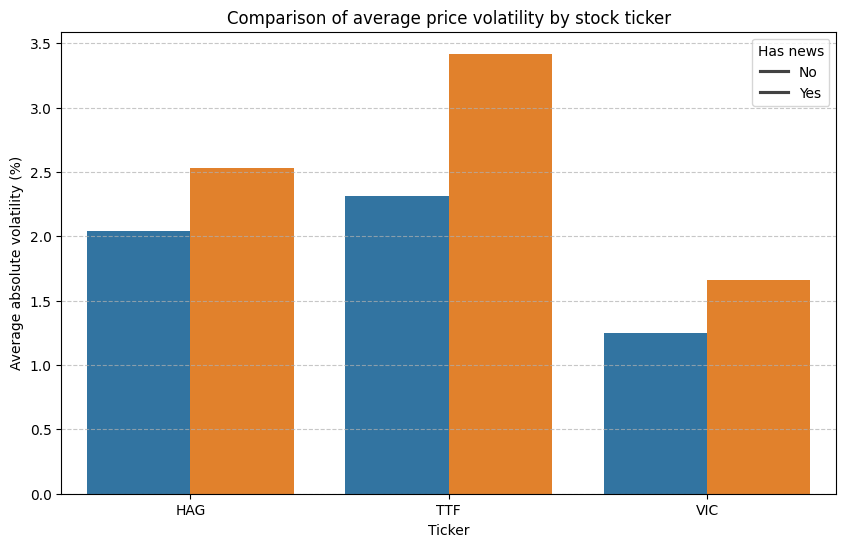

has_news,No news,Has news
ticker,,
HAG,2.037556,2.527549
TTF,2.316478,3.417865
VIC,1.247884,1.657648


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Classify days with and without news
df_all_trading_days['has_news'] = df_all_trading_days['title'].notna()

# Calculate average absolute volatility by ticker and news status
ticker_volatility = df_all_trading_days.groupby(['ticker', 'has_news'])['price_change_pct'].apply(lambda x: x.abs().mean()).reset_index()

# Plot comparison chart
plt.figure(figsize=(10, 6))
sns.barplot(data=ticker_volatility, x='ticker', y='price_change_pct', hue='has_news')

plt.title('Comparison of average price volatility by stock ticker')
plt.ylabel('Average absolute volatility (%)')
plt.xlabel('Ticker')
plt.legend(title='Has news', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display detailed data table
display(ticker_volatility.pivot(index='ticker', columns='has_news', values='price_change_pct').rename(columns={False: 'No news', True: 'Has news'}))

**Conclusion**:

*   Average Volatility (News): 2.35%
*   Average Volatility (No News): 1.87%
*   P-value: 0.0000113 Conclusion: Since the P-value is significantly lower than 0.05, we reject the null hypothesis. There is a statistically significant difference, proving that news events drive higher price volatility.



**3.2. Univariate Analysis**

***3.2.1. % Price Change***

/tmp/ipykernel_205/279623801.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


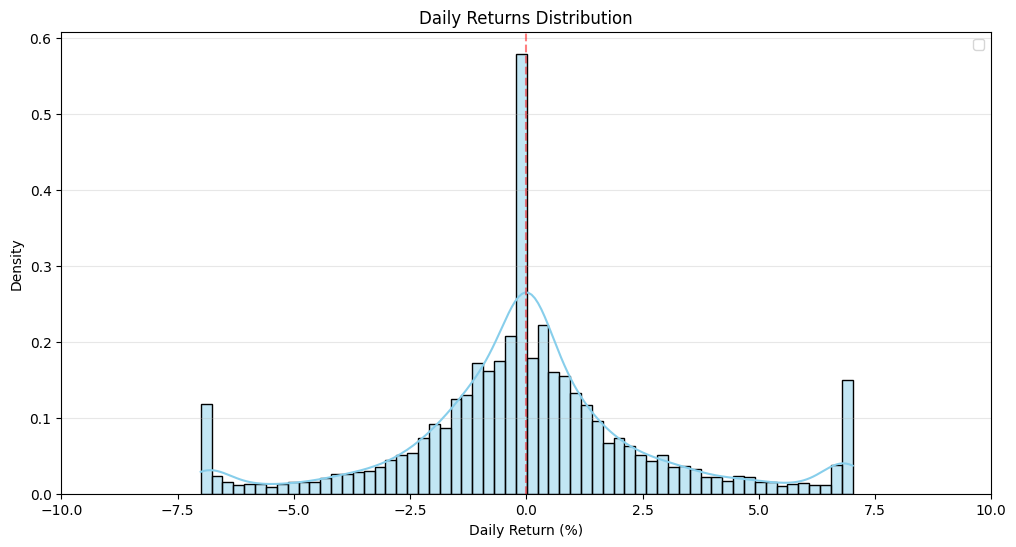

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.histplot(data=df_all_trading_days,
             x='price_change_pct', color='skyblue', kde=True, stat="density", alpha=0.5)

plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Daily Returns Distribution')
plt.xlabel('Daily Return (%)')

plt.ylabel('Density')
plt.legend()
plt.xlim(-10, 10)
plt.grid(axis='y', alpha=0.3)
plt.show()

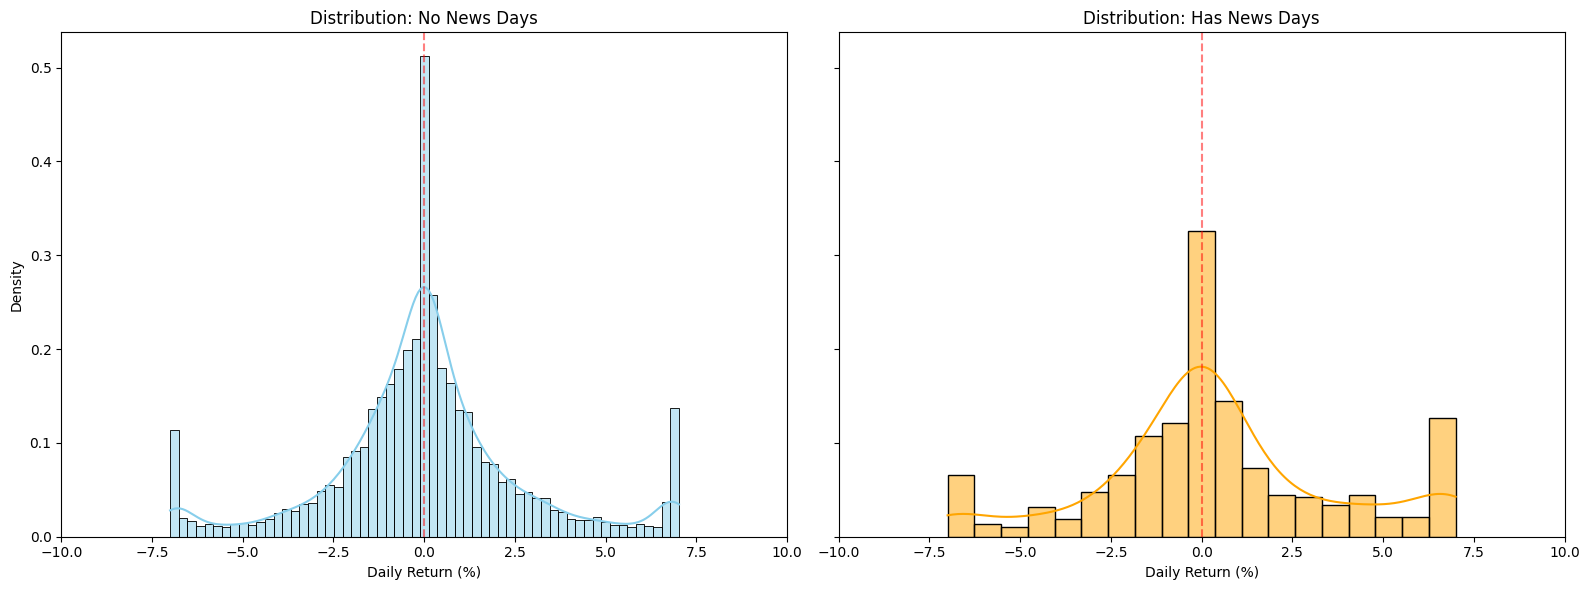

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: No News
sns.histplot(data=df_all_trading_days[df_all_trading_days['has_news'] == False],
             x='price_change_pct', color='skyblue', kde=True, stat="density", ax=axes[0])
axes[0].set_title('Distribution: No News Days')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_xlim(-10, 10)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

# Plot 2: Has News
sns.histplot(data=df_all_trading_days[df_all_trading_days['has_news'] == True],
             x='price_change_pct', color='orange', kde=True, stat="density", ax=axes[1])
axes[1].set_title('Distribution: Has News Days')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_xlim(-10, 10)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



1.   **No News Days:** The distribution is highly concentrated around 0% (high peak), meaning the stock price stays relatively stable on most days without news.
2. **Has News Days:** The distribution is much flatter and wider. You can clearly see a higher frequency of returns in the -5% to -10% and +5% to +10% ranges compared to the 'No News' group. This visually confirms the 'fat tails' and increased risk/volatility associated with news events.



**3.2.2. Sentiment Score**

In [ ]:
df = pd.read_excel('/content/result.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 664 entries, 0 to 663
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticker            664 non-null    object 
 1   text              664 non-null    object 
 2   pred_label        664 non-null    object 
 3   confidence        664 non-null    float64
 4   prob_NEG          664 non-null    float64
 5   prob_POS          664 non-null    float64
 6   prob_NEU          664 non-null    float64
 7   Sentiment_Score   664 non-null    float64
 8   Price_Change_Pct  664 non-null    float64
dtypes: float64(6), object(3)
memory usage: 46.8+ KB


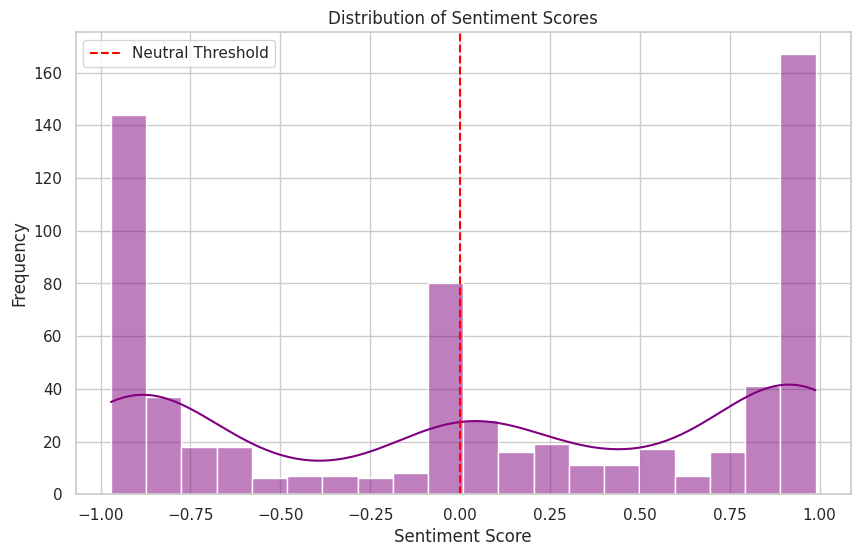

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['Sentiment_Score'], kde=True, color='purple', bins=20)

plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral Threshold')
plt.legend()
plt.show()

**3.3. Bivariate Analysis**

**3.3.1. %Price_change vs. Sentiment_Score**

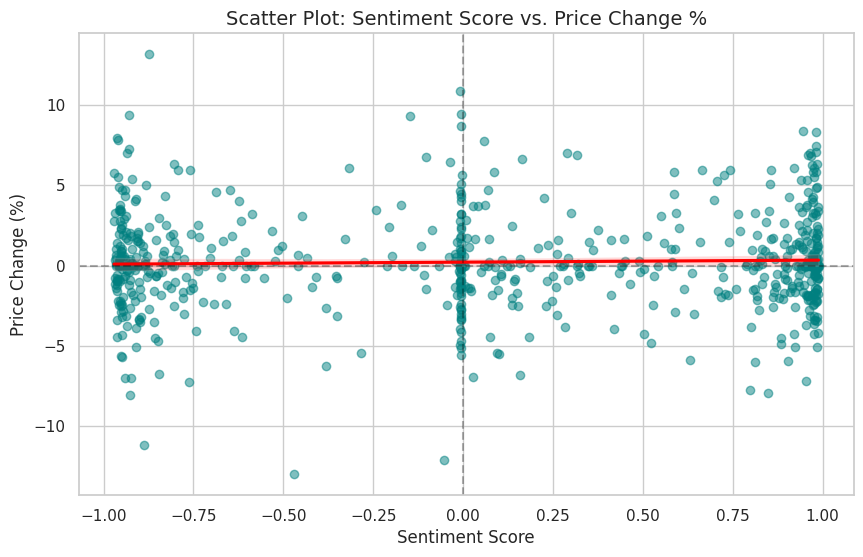

Pearson Correlation Coefficient: 0.0309


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Create the scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Sentiment_Score', y='Price_Change_Pct',
            scatter_kws={'alpha':0.5, 'color':'teal'},
            line_kws={'color':'red'})

# Add visual guides
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)

# Titles and Labels
plt.title('Scatter Plot: Sentiment Score vs. Price Change %', fontsize=14)
plt.xlabel('Sentiment Score', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)

plt.show()

# Calculate and display correlation coefficient
corr_coef = df['Sentiment_Score'].corr(df['Price_Change_Pct'])
print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")

### **Why is the Correlation Weak (0.0309)?**

Based on the analysis, the Pearson correlation coefficient is nearly zero. Here are the primary reasons:

*   **Information Leakage**: Prices often move *before* news is published on official channels (insider trading or advanced forecasting).
*   **Volume vs. Sentiment**: A very positive article might have low trading volume, while a slightly negative article might trigger a massive sell-off. Sentiment score doesn't account for 'weight'.
*   **Market Context**: During a 'Bear Market', even positive news might not lift a stock price because the overall trend is downward.
*   **Sentiment Model Limitations**: NLP models might misinterpret financial jargon or sarcasm, leading to scores that don't perfectly reflect the financial implication of the text.
*   **Daily Aggregation**: Intraday volatility is smoothed out when using daily close prices, hiding the immediate 'spike' that news might have caused.

**3.3.2. Return vs. Label**

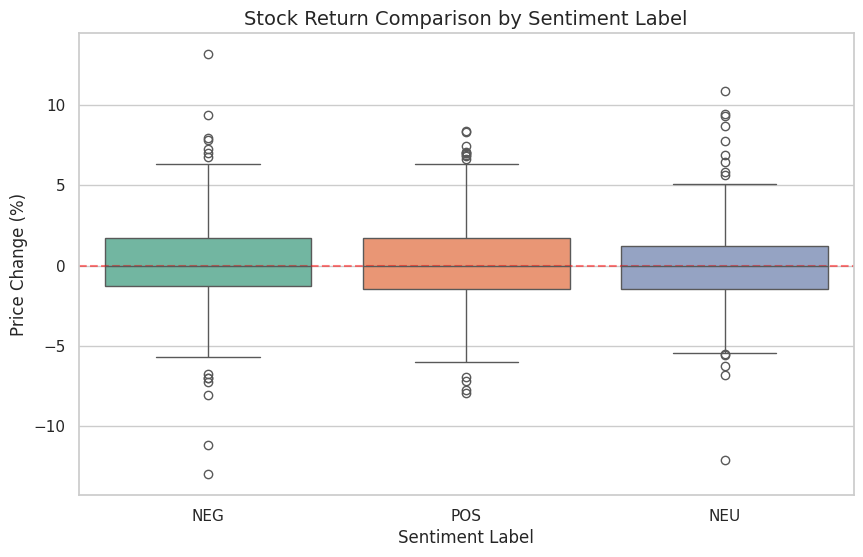

Average Price Change by Label:
pred_label
NEG    0.198148
NEU    0.025518
POS    0.359824
Name: Price_Change_Pct, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# Using a boxplot to show distribution of returns for each label
sns.boxplot(data=df, x='pred_label', y='Price_Change_Pct', palette='Set2', hue='pred_label', legend=False)

plt.title('Stock Return Comparison by Sentiment Label', fontsize=14)
plt.xlabel('Sentiment Label', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.show()

# Calculate average return per label
avg_return = df.groupby('pred_label')['Price_Change_Pct'].mean()
print("Average Price Change by Label:")
print(avg_return)

### **Why do Negative News (NEG) have positive average returns?**

There are several reasons why the data shows a +0.198% return despite negative sentiment:

1. **'Sell the Rumor, Buy the Fact'**: Often, the market anticipates bad news and prices drop *before* the news is published. When the news finally arrives, if it isn't as bad as feared, investors start buying, causing the price to rise.
2. **Broader Market Trend (Bull Market)**: If the overall VN-Index or the specific industry is in a strong uptrend, individual negative news for a stock might only slow down its growth or cause a temporary dip that is quickly bought up by the market.
3. **Relief Rallies**: Sometimes negative news brings 'certainty'. For example, if a company is fined, the uncertainty of 'how much' is gone. The market may react positively because the worst-case scenario is now known and managed.
4. **Data Aggregation**: Since we use daily Close prices, a stock might drop sharply when news breaks but recover by the end of the trading session, resulting in a positive daily return.
5. **Sample Size**: With only 664 news samples across several years, a few highly positive days for certain stocks (HAG, VIC, TTF) that happened to have 'Negative' news could skew the average upward.

**3.3.3. Attention vs. Volume**

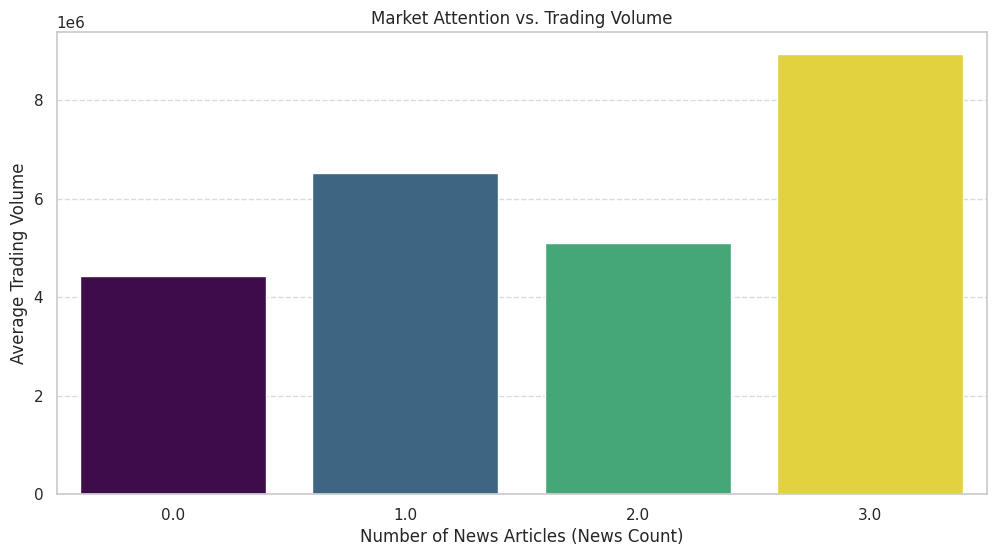

Correlation between News Count and Trading Volume: 0.0680


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count news per ticker per Target_Date
df_news_counts = df_news_filtered.groupby(['Target_Date', 'ticker']).size().reset_index(name='news_count')

# 2. Merge news counts with price data using normalized dates
df_volume_attention = pd.merge(
    df_price,
    df_news_counts,
    left_on=[df_price['time'].dt.normalize(), 'ticker'],
    right_on=[df_news_counts['Target_Date'].dt.normalize(), 'ticker'],
    how='left'
)

# Fill NaN news_count with 0
df_volume_attention['news_count'] = df_volume_attention['news_count'].fillna(0)

# 3. Aggregate data by news_count to see average volume per level of attention
avg_vol_by_attention = df_volume_attention.groupby('news_count')['volume'].mean().reset_index()

# 4. Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_vol_by_attention, x='news_count', y='volume', palette='viridis', hue='news_count', legend=False)

plt.title('Market Attention vs. Trading Volume')
plt.xlabel('Number of News Articles (News Count)')
plt.ylabel('Average Trading Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate correlation
correlation = df_volume_attention[['news_count', 'volume']].corr().iloc[0, 1]
print(f"Correlation between News Count and Trading Volume: {correlation:.4f}")

While the correlation is numerically weak, the visual trend confirms that news events do act as a catalyst for trading activity, drawing more attention and higher liquidity to the stock compared to average trading days.



# **4. Advanced EDA**

**4.1. Asymmetry Effect**

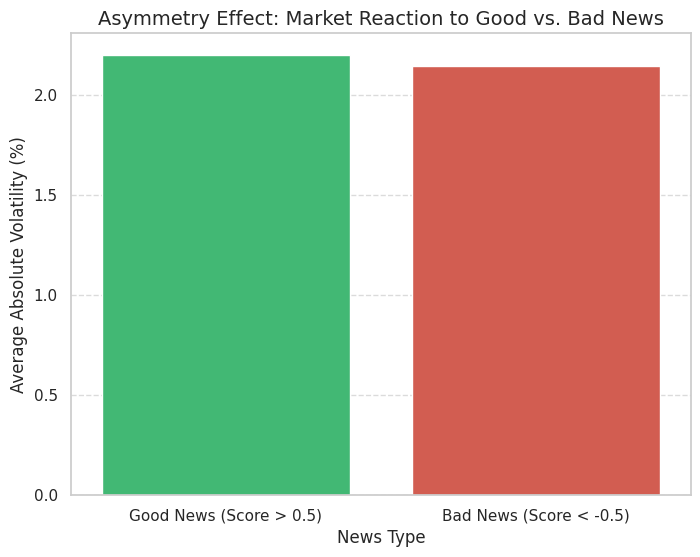

Average Absolute Volatility for Good News: 2.20%
Average Absolute Volatility for Bad News: 2.14%

Conclusion: The market reacts more strongly to good news (FOMO).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Split data into Good News and Bad News based on thresholds
good_news = df[df['Sentiment_Score'] > 0.5].copy()
bad_news = df[df['Sentiment_Score'] < -0.5].copy()

# 2. Calculate Absolute Mean Return |Return|
avg_abs_return_good = good_news['Price_Change_Pct'].abs().mean()
avg_abs_return_bad = bad_news['Price_Change_Pct'].abs().mean()

# 3. Create a comparison DataFrame
asymmetry_df = pd.DataFrame({
    'News Type': ['Good News (Score > 0.5)', 'Bad News (Score < -0.5)'],
    'Avg Absolute Return (%)': [avg_abs_return_good, avg_abs_return_bad]
})

# 4. Visualization
plt.figure(figsize=(8, 6))
sns.barplot(data=asymmetry_df, x='News Type', y='Avg Absolute Return (%)', palette=['#2ecc71', '#e74c3c'], hue='News Type', legend=False)

plt.title('Asymmetry Effect: Market Reaction to Good vs. Bad News', fontsize=14)
plt.ylabel('Average Absolute Volatility (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print(f"Average Absolute Volatility for Good News: {avg_abs_return_good:.2f}%")
print(f"Average Absolute Volatility for Bad News: {avg_abs_return_bad:.2f}%")

if avg_abs_return_bad > avg_abs_return_good:
    print("\nConclusion: The market shows an Asymmetry Effect where it reacts more strongly to bad news (Panic Selling).")
else:
    print("\nConclusion: The market reacts more strongly to good news (FOMO).")

**4.2. Word Cloud**

In [ ]:
!pip install wordcloud underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.3 MB/s eta 0:00:00


In [ ]:
#StopWords
basic_stopwords = set("""
và là của có trong một những các đã đang sẽ cho khi thì mà được với về từ này kia đó đây ấy vì do nên nếu cũng chỉ lại ra lên xuống vào đi đến rồi như
tôi nhà đầu tư thị trường người công ty doanh nghiệp đơn vị tổ chức vẫn trên trước sau cùng hơn ông bà
""".split())

news_stopwords = set("""
theo cho biết ghi nhận cho rằng nhận định đánh giá thông tin dữ liệu báo cáo công bố
cập nhật tin tức phiên ngày tháng năm quý sáng chiều hôm nay hôm qua
trong đó liên quan bao gồm đối với tại đây hiện nay vừa qua thời gian gần đây
ngày tuần tháng quý năm
""".split())

finance_neutral = set("""
cổ phiếu cp mã chứng khoán sàn hose hnx upcom vnindex vn30 index
thị trường thanh khoản khối lượng giao dịch nhà đầu tư dòng tiền
niêm yết đăng ký giao dịch vốn điều lệ cổ đông doanh nghiệp
""".split())

tickers_stopwords = set("""
hag ttf acb bcm bid bvh ctg fpt gas gvr hdb hpg mbb msn mwg plx pow sab shb ssb ssi stb tcb tpb vcb vhm vib vic vjc vnm vpb vre
""".split())

numeric_stopwords = set("""
tỷ triệu nghìn phần trăm đồng vnđ usd lần
""".split())

neutral_verbs = set("""
tăng giảm đi lên đi xuống biến động điều chỉnh giao dịch mua bán
ghi nhận đạt mức dao động mở cửa đóng cửa
""".split())

special_words = set(['chứng_khoán', 'giao_dịch', 'thị_trường', 'vingroup','công_ty', 'cổ_phiếu'])

stopwords_set = (
    basic_stopwords
    | news_stopwords
    | finance_neutral
    | tickers_stopwords
    | numeric_stopwords
    | neutral_verbs
    | special_words
)

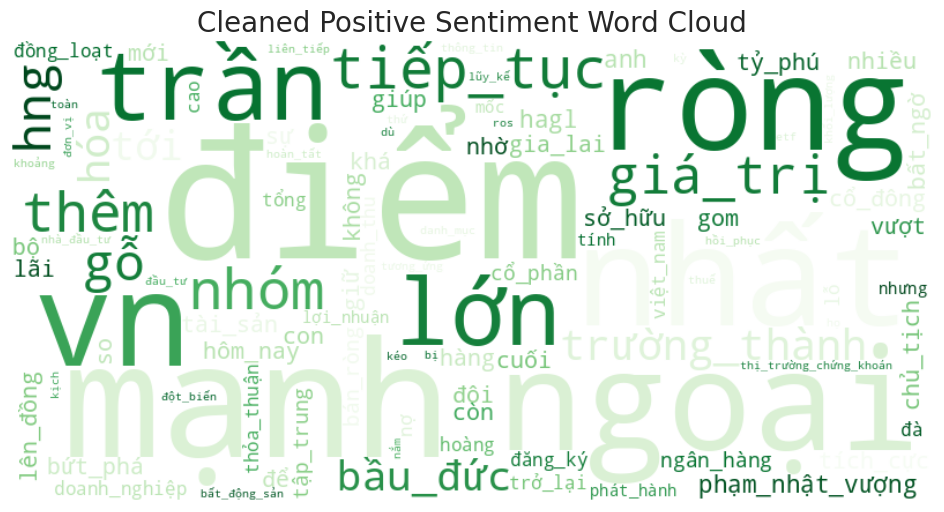

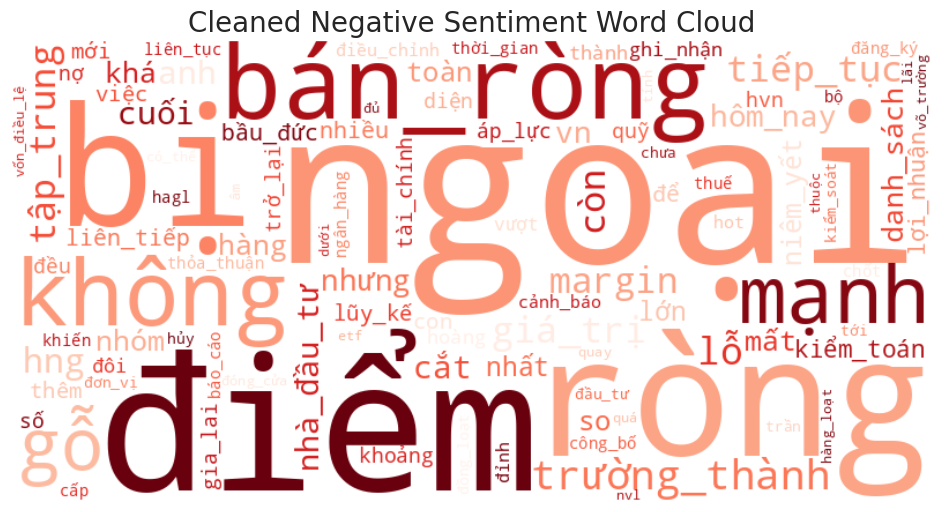

In [ ]:
import pandas as pd
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from underthesea import word_tokenize

# =========================
# 1. STOPWORDS
# =========================
stopwords_raw = stopwords_set

# =========================
# 2. TOKENIZE STOPWORDS
# =========================
stopwords_final = set()
for w in stopwords_raw:
    tokens = word_tokenize(w, format="text").split()
    stopwords_final.update(tokens)

# =========================
# 3. CLEAN TEXT FUNCTION
# =========================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', ' ', text)          # xóa số
    text = re.sub(r'[^\w\s]', ' ', text)      # xóa dấu câu
    return text

# =========================
# .4 TEXT PROCESSING: CLEAN -> TOKENIZE -> REMOVE STOPWORDS
# =========================
def process_text(text):
    text = clean_text(text)
    tokens = word_tokenize(text, format="text").split()
    tokens = [w for w in tokens if w not in stopwords_final and len(w) > 1]
    return tokens

df['tokens_cleaned'] = df['text'].apply(process_text)

# =========================
# 5. GET TOKEN BASED ON SENTIMENT
# =========================
neg_tokens = [token for tokens in df[df['pred_label'] == 'NEG']['tokens_cleaned'] for token in tokens]
pos_tokens = [token for tokens in df[df['pred_label'] == 'POS']['tokens_cleaned'] for token in tokens]

neg_freq = Counter(neg_tokens)
pos_freq = Counter(pos_tokens)

# =========================
# 6. DRAW WORD CLOUD
# =========================
def plot_wordcloud(freq, title, color_map):
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap=color_map,
                          max_words=100).generate_from_frequencies(freq)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

# =========================
# 7. DRAW WORD CLOUD FOR POS AND NEG
# =========================
if pos_freq:
    plot_wordcloud(pos_freq, 'Cleaned Positive Sentiment Word Cloud', 'Greens')
if neg_freq:
    plot_wordcloud(neg_freq, 'Cleaned Negative Sentiment Word Cloud', 'Reds')